# Tutorial 1: Introduction to NeuroVLM

This tutorial provides an overview of NeuroVLM, a multimodal framework for text-to-brain and brain-to-text applications in neuroimaging. You'll learn about:

1. Fetching models and datasets from HuggingFace
2. Types of models and architectures
3. Available datasets
4. Basic concepts: text-to-brain and brain-to-text

## 1. Setup and Installation

First, let's import the necessary modules and fetch the pre-trained models and datasets.

In [ ]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from neurovlm import NeuroVLM
from neurovlm.data import fetch_data, load_dataset, load_latent

# Fetch all models and datasets from HuggingFace
fetch_data()

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Data fetch complete. Cache directory: /Users/borng/.cache/huggingface/hub


'/Users/borng/.cache/huggingface/hub'

## 2. Model Architectures

NeuroVLM uses several model architectures working together:

### Text Encoder (SPECTER2)
- Encodes scientific text (titles, abstracts) into 768-dimensional embeddings
- Pre-trained on scientific literature for domain-specific understanding
- Handles variable-length text input

### Autoencoder
- **Encoder**: Compresses 28,542-dimensional brain activation maps to 384-dimensional latent space
- **Decoder**: Reconstructs brain maps from latent representations
- Enables efficient storage and manipulation of neuroimaging data

### Projection Heads
- **Contrastive (InfoNCE)**: Projects text and brain embeddings into shared space for retrieval
- **Generative (MSE)**: Projects text embeddings to brain latent space for generation

### Architecture Overview

```
Text → SPECTER2 → Projection Head → Shared Space ← Projection Head ← Autoencoder.Encoder ← Brain
                                                                                             |
Text → SPECTER2 → Projection Head → Brain Latent → Autoencoder.Decoder → Generated Brain  ←┘
```

## 3. Available Datasets

NeuroVLM includes several curated datasets:

### Text Datasets
- **PubMed**: ~30K neuroimaging publications with titles and abstracts
- **NeuroWiki**: Neuroscience concepts from Wikipedia
- **Cognitive Atlas**: Cognitive concepts, tasks, and disorders
- **Networks**: Canonical brain network descriptions

### Brain Image Datasets
- **PubMed Images**: Brain activation maps from published studies
- **NeuroVault**: Community-contributed brain maps
- **Network Atlases**: Canonical brain networks (multiple atlases)

Let's explore these datasets:

In [18]:
# Load text datasets
publications = load_dataset("pubmed_text")
print(f"PubMed publications: {len(publications)} papers")
print(f"Columns: {list(publications.columns)}")
print("\nExample publication:")
publications.head(10)

PubMed publications: 30826 papers
Columns: ['pmid', 'pmcid', 'doi', 'name', 'description', 'train', 'test', 'val']

Example publication:


,pmid,pmcid,doi,name,description,train,test,val
0,24911975,NaN,10.1371/journal.pone.0099222,Acute aerobic exercise increases cortical acti...,There is increasing evidence that acute aerobi...,True,False,False
1,22884992,NaN,10.1016/j.dcn.2012.07.001,Developmental differences in the neural correl...,Despite vast knowledge on the behavioral proce...,True,False,False
2,15722210,NaN,10.1016/j.cogbrainres.2004.09.011,The neural substrate of arithmetic operations ...,Recent functional neuroimaging studies have be...,True,False,False
3,21930137,NaN,10.1016/j.neuropsychologia.2011.09.006,Neural processing associated with comprehensio...,"In daily communication, we often use indirect ...",True,False,False
4,21930160,NaN,10.1097/gme.0b013e3181cc49e9,Postmenopausal hormone use impact on emotion p...,Despite considerable evidence for potential ef...,True,False,False
5,21930304,NaN,10.1016/j.jad.2011.08.020,Neural correlates of disbalanced motor control...,BACKGROUND: Motor retardation is a common symp...,True,False,False
6,21932265,NaN,10.1002/hbm.21385,Propofol disrupts functional interactions betw...,Current theories suggest that disrupting corti...,True,False,False
7,21932266,NaN,10.1002/hbm.21373,Functionally distinct regions for spatial proc...,There has been much debate recently over the f...,True,False,False
8,21933718,NaN,10.1016/j.neuroimage.2011.09.004,Imitation components in the human brain: an fM...,Human ability to imitate movements is instanti...,False,True,False
9,21935391,NaN,10.1371/journal.pone.0024253,Spatial language processing in the blind: evid...,Neuropsychological and imaging studies have sh...,True,False,False


In [20]:
# Cognitive Atlas concepts
cogatlas = load_dataset("cogatlas")
print(f"\nCognitive Atlas concepts: {len(cogatlas)}")
print("\nExample concepts:")
cogatlas.head(10)


Cognitive Atlas concepts: 911

Example concepts:


,term,definition,alias
0,abductive reasoning,The process of adopting an explanatory hypothe...,None
1,abstract analogy,High-level analogy that retains general inform...,None
2,abstract knowledge,Knowledge that is general and not tied to a sp...,None
3,acoustic coding,A type of short term memory coding that repres...,None
4,acoustic encoding,The processing and encoding of auditory input ...,None
5,acoustic phonetic processing,The cognitive ability to discriminate items on...,None
6,acoustic processing,The extraction of information from signals pro...,None
7,action,The bringing about of an alteration by force o...,None
8,action initiation,The facilitation or initiation of an act.,None
9,action perception,The perception of an action being performed by...,None


In [21]:
# NeuroWiki
neurowiki = load_dataset("wiki")
print(f"\nNeuroWiki entries: {len(neurowiki)}")
print("\nExample entries:")
neurowiki.head(10)


NeuroWiki entries: 38410

Example entries:


,title,summary,cos_sim_summary,cos_sim_title,cos_sim_avg,cos_sim_invalid,cos_sim,id
0,Membrane potential,Membrane potential (also transmembrane potenti...,0.772090,1.000000,0.886045,0.167787,0.718258,833aec91
1,Ion channel,Ion channels are pore-forming membrane protein...,0.703097,1.000000,0.851549,0.138511,0.713037,5736c326
2,Calcium imaging,Calcium imaging is a microscopy technique to o...,0.802223,1.000000,0.901111,0.232906,0.668205,0c744fe2
3,Signal processing,Signal processing is an electrical engineering...,0.757949,1.000000,0.878974,0.219474,0.659500,a5c71b00
4,Ion channel pore,There are two distinctive features of ion chan...,0.703097,0.777337,0.740217,0.101555,0.638663,f9d03533
5,Corpus callosum,"The corpus callosum (Latin for ""tough body""), ...",0.719148,1.000000,0.859574,0.226570,0.633003,1778086e
6,Complications of traumatic brain injury,"Traumatic brain injury (TBI, physical trauma t...",0.714219,0.872134,0.793176,0.162419,0.630757,259064c0
7,Metacognition,Metacognition is an awareness of one's thought...,0.779177,1.000001,0.889589,0.264607,0.624982,a3d483d8
8,Huntington's disease-like syndrome,Huntington's disease-like syndromes (HD-like s...,0.727485,0.916222,0.821854,0.198028,0.623825,a1db5686
9,Fourier transform,"In mathematics, the Fourier transform (FT) is ...",0.637224,1.000000,0.818612,0.194800,0.623812,34567425


In [22]:
# Network atlases
networks = load_dataset("networks_canonical")
print(f"\nCanonical networks: {len(networks)}")
print("\nExample networks:")
networks.head(10)


Canonical networks: 8

Example networks:


,title,description
0,Language,Language network (LAN; perisylvian language ne...
1,Auditory,Auditory network (AUD; auditory cortex network...
2,Default Mode,Default mode network (DMN; default network; de...
3,Frontoparietal Control,Frontoparietal control network (FPCN; frontopa...
4,Attention,Dorsal attention network [SEP] Primary regions...
5,Visual,Visual network (VIS; occipital visual network)...
6,Motor,Motor network (motor/sensorimotor network; SMN...
7,Cingulo-Opercular,Salience network (SN; cingulo-opercular networ...


## 4. Text-to-Brain and Brain-to-Text

NeuroVLM supports bidirectional querying:

### Text-to-Brain
Given a text query, NeuroVLM can:
1. **Generate** brain activation patterns (generative approach)
2. **Retrieve** similar brain maps from datasets (contrastive approach)

### Brain-to-Text
Given a brain activation map, NeuroVLM can:
1. **Retrieve** related scientific text, concepts, or descriptions
2. **Generate** text descriptions using language models (see Tutorial 4)

## 5. Quick Examples

Let's see both directions in action:

In [6]:
# Initialize the model
# Note: Models are lazy-loaded on first use (not here).
# The first call to .text() will load SPECTER (~500MB transformer) into RAM,
# which typically takes 1-3 minutes. All subsequent calls are < 5 seconds.
nvlm = NeuroVLM(device="cpu")

print("Model initialized successfully!")

Model initialized successfully!


### Text-to-Brain: Generate brain maps from text

There are adapters available but none are activated for the forward pass.


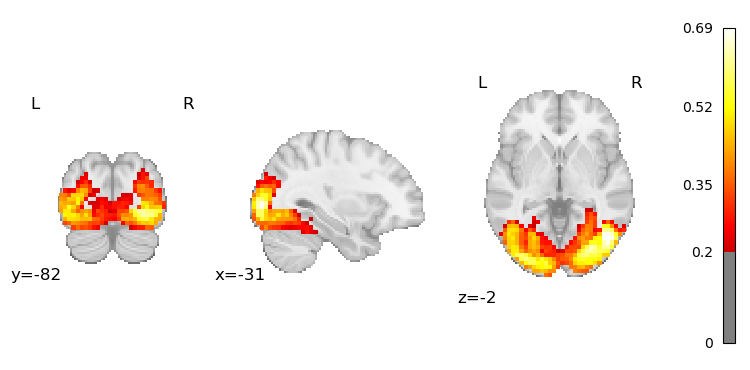

In [7]:
# Generate a brain map from text
# First run: loads SPECTER + projection heads + autoencoder into RAM (~1-3 min total)
# Subsequent runs in the same kernel session: < 5 seconds
# All computation runs on CPU - no MPS or CUDA used
result = nvlm.text("visual processing").to_brain(head="mse")

# Plot the generated brain map  
result.plot(threshold=0.2);

### Text-to-Brain: Retrieve similar brain maps

In [9]:
# Find brain maps similar to the text query
result = nvlm.text("working memory").to_brain(head="infonce")

# Show top matches
top = result.top_k(3)
top

,dataset,dataset_index,title,description,cosine_similarity
0,networks,38,HCPICA,ICA11,0.322152
1,networks,10,Du,FPN-A,0.300826
2,networks,84,Shirer,Visuospatial,0.290263
3,neurovault,833,Exploring the role of the posterior middle tem...,Making sense of the world around us depends up...,0.403994
4,neurovault,1105,Identification of Two Distinct Working Memory-...,Working memory (WM) is an important cognitive ...,0.398966
5,neurovault,2900,Evidence for Hierarchical Cognitive Control in...,"In non-habitual situations, cognitive control ...",0.377900
6,pubmed,1581,Control networks and hemispheric asymmetries i...,Neuropsychological research has consistently d...,0.405712
7,pubmed,6428,Salience maps in parietal cortex: imaging and ...,Models of spatial attention are often based on...,0.405312
8,pubmed,22999,Effects of in-Scanner Bilateral Frontal tDCS o...,Working memory is an executive memory process ...,0.399832


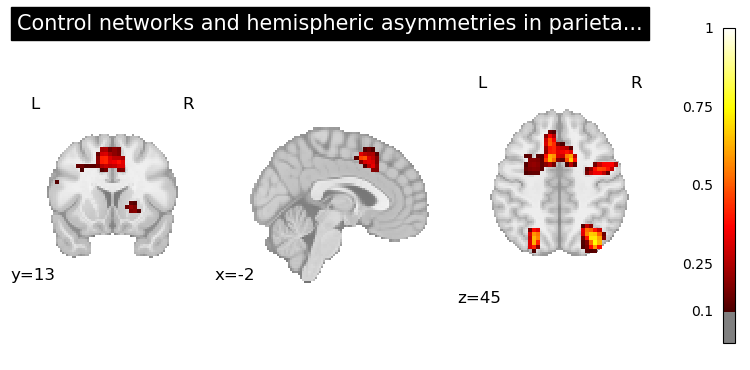

In [11]:
# Visualize the top match
top.plot_row(6, threshold=0.1);

### Brain-to-Text: Find text descriptions for brain maps

In [15]:
# Load example network atlases
networks_neuro = load_latent("networks_neuro")

# Use the Default Mode Network as a query
dmn = networks_neuro["Du"]["AUD"]

# Find related text
result = nvlm.brain(dmn).to_text()
top = result.top_k(5).query("cosine_similarity > 0.4") # return up to 5 examples per dataset within threshold
top

,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665
5,networks,Auditory,Auditory network (AUD; auditory cortex network...,0.470543
10,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
11,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
12,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
13,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401


## 6. Summary

In this tutorial, you learned:

1. **How to fetch models and datasets** from HuggingFace using `fetch_data()`
2. **Model architectures** in NeuroVLM:
   - SPECTER2 text encoder
   - Autoencoder for brain compression
   - Contrastive and generative projection heads
3. **Available datasets**:
   - Text: PubMed, NeuroWiki, Cognitive Atlas, Networks
   - Brain: PubMed images, NeuroVault, Network atlases
4. **Text-to-brain and brain-to-text** concepts

In the following tutorials, you'll learn:
- **Tutorial 2**: Contrastive retrieval for brain-to-text and text-to-brain
- **Tutorial 3**: Generative text-to-brain mapping
- **Tutorial 4**: Generative brain-to-text with LLMs